In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [11]:
df = pd.read_csv("/content/kc_house_data (1).csv")

In [12]:
print(df.head())


           id             date     price  bedrooms  bathrooms  sqft_living  \
0  7129300520  20141013T000000  221900.0         3       1.00         1180   
1  6414100192  20141209T000000  538000.0         3       2.25         2570   
2  5631500400  20150225T000000  180000.0         2       1.00          770   
3  2487200875  20141209T000000  604000.0         4       3.00         1960   
4  1954400510  20150218T000000  510000.0         3       2.00         1680   

   sqft_lot  floors  waterfront  view  ...  grade  sqft_above  sqft_basement  \
0      5650     1.0           0     0  ...      7        1180              0   
1      7242     2.0           0     0  ...      7        2170            400   
2     10000     1.0           0     0  ...      6         770              0   
3      5000     1.0           0     0  ...      7        1050            910   
4      8080     1.0           0     0  ...      8        1680              0   

   yr_built  yr_renovated  zipcode      lat     lo

In [13]:
if "id" in df.columns:
    df.drop("id", axis=1, inplace=True)

if "date" in df.columns:
    df.drop("date", axis=1, inplace=True)

In [14]:
imputer = SimpleImputer(strategy="mean")
df[df.columns] = imputer.fit_transform(df)

In [15]:
X = df.drop("price", axis=1)
y = df["price"]


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [17]:
model = LinearRegression()

In [18]:
model.fit(X_train, y_train)

LinearRegression()

In [19]:
y_pred = model.predict(X_test)

In [20]:
print("\nMean Absolute Error:", mean_absolute_error(y_test, y_pred))

print("\nMean Squared Error:", mean_squared_error(y_test, y_pred))

print("\nRoot Mean Squared Error:", np.sqrt(mean_squared_error(y_test, y_pred)))

print("\nR2 Score:", r2_score(y_test, y_pred))


Mean Absolute Error: 127610.70272607327

Mean Squared Error: 45224874244.72454

Root Mean Squared Error: 212661.40751138778

R2 Score: 0.7011994125098217


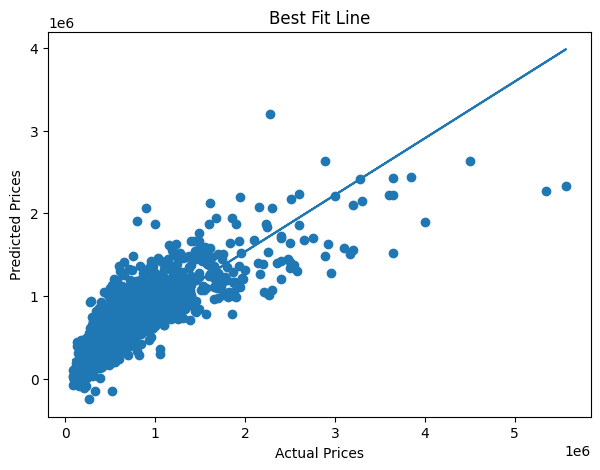

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Scatter Plot
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred)

# Draw Best Fit Line
z = np.polyfit(y_test, y_pred, 1)
p = np.poly1d(z)

plt.plot(y_test, p(y_test))

plt.title("Best Fit Line")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.show()